# 07 - Streamlit Deployment & Operational Integration
### AI-Powered Predictive Bed Demand Forecasting - Albion Care Network

**Notebook 7 of 7** | Deployment Phase

---

## Objectives

This final notebook implements the brief's Deployment Phase scope in full:

1. Deploy an interactive forecasting application using Streamlit, exposing the daily/weekly
   forecasts, the four scenario simulations, and the SHAP explainability layer built in
   Notebooks 04-06.
2. Implement operational alerts, using the 85%/90% bottleneck thresholds established in
   Notebook 02.
3. Establish a continuous learning pipeline that monitors forecast performance over time and
   retrains the model, addressing the brief's explicit "continuous learning pipeline that
   improves forecasting performance over time" objective.
4. Produce the documentation and handover materials (README, model card) a hospital
   operations team would need to run and trust this tool without the original author present.
5. Close the project with a single summary connecting every notebook back to the original
   business problem.

## Background

Notebooks 01-06 took Albion Care Network from six fragmented raw datasets to a validated,
explainable, scenario-tested LightGBM forecasting model. This notebook is the last mile: making
that model something a hospital planner can actually open and use, with guardrails (alerts),
a plan for staying accurate over time (monitoring and retraining), and documentation for
whoever operates it next.

## Inputs

- All model artefacts from Notebooks 04-06 (`models/`)
- `data/processed/daily_feature_panel.parquet`

## Outputs

- `app/app.py`: the deployed Streamlit application (self-contained, with its own `data/` and
  `models/` copies).
- `monitoring/bed_demand_monitoring.py`: the continuous learning pipeline (monitoring, drift detection,
  retraining).
- `README.md` and `model_card.md`: handover documentation.


In [9]:
# --- Setup & configuration -------------------------------------------------
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import lightgbm as lgb
import subprocess
import time
import requests
import sys
from pathlib import Path
from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)

PROC_DIR = Path('../data/processed')
MODEL_DIR = Path('../models')
APP_DIR = Path('../app')
MONITORING_DIR = Path(r'C:\Users\ifech\OneDrive\Desktop\Albion Care Network\hospital_occupancy_forecast\monitoring')

EXCLUDE_COLS = ['hospital_id', 'ward', 'bed_type', 'date', 'target_next_day_occupied',
                'target_next_week_occupied', 'split', 'median_los_hours']
CAT_COLS = ['hospital_id', 'ward', 'bed_type']

daily = pd.read_parquet(PROC_DIR / 'daily_feature_panel.parquet')
FEATURE_COLS = [c for c in daily.columns if c not in EXCLUDE_COLS]
for c in FEATURE_COLS:
    if 'pyarrow' in str(daily[c].dtype):
        daily[c] = daily[c].astype('float64')

print('Environment ready.')
print('App directory contents:', [p.name for p in APP_DIR.iterdir()])


Environment ready.
App directory contents: ['app.py']


---
## Section 1 - Deployment Architecture

The deployed application is a self-contained folder (`app/`), independent of the notebooks
directory, so it can be copied or shared without needing the full project repository:

```
app/
  app.py              # the Streamlit application
  data/               # daily_feature_panel, hospital_reference, hourly_ed_arrivals_panel
  models/             # lightgbm_daily_tuned, lightgbm_weekly, lightgbm_hourly_ed, SHAP background
```

The app itself has five parts, directly mapping to the brief's requirements and the prior six
notebooks' outputs:

1. **Hospital/ward/bed-type selector** (sidebar), covering ICU, general wards, and specialist
   units, per the brief's "predict bed occupancy across ICU, general wards, and specialist
   units" objective.
2. **Daily and weekly forecast KPIs**, using the LightGBM models selected in Notebook 05.
3. **Operational alert banner**, using the 85%/90% thresholds from Notebook 02 Section 7.1.
4. **Scenario simulator**, reproducing the four brief-named scenarios validated in Notebook 06,
   with an adjustable intensity slider.
5. **SHAP explainability panel**, showing which features drove that specific ward's forecast,
   using the same `TreeExplainer` approach from Notebook 06 Section 3.

Run with: `streamlit run app.py` from inside the `app/` directory.


In [10]:
with open(APP_DIR / 'app.py') as f:
    app_source = f.read()
print(f'app.py: {len(app_source.splitlines())} lines')
print()
print(app_source[:600])
print('...')


app.py: 314 lines

"""
Albion Care Network - Predictive Bed Demand Forecasting
Streamlit operational dashboard.

Run with: streamlit run app.py
"""

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
import streamlit as st
from pathlib import Path

# -----------------------------------------------------------------------------
# Page configuration
# -----------------------------------------------------------------------------
st.set_page_config(
    page_title="Albion Care Network - Bed Demand Forecasting",

...


---
## Section 2 - Testing the Deployed App

Before handing this over, we run the app exactly as an operator would (`streamlit run app.py`)
in headless mode, confirm the server starts without raising an exception, and confirm it
actually serves a page and passes its own health check, rather than just checking the source
code parses.


In [11]:
# Invoked as `python -m streamlit`, using this exact interpreter (sys.executable), rather than
# a bare "streamlit" command. A bare command name relies on the OS successfully resolving it
# from PATH, which is exactly the kind of thing that can silently differ between machines
# (in particular, on Windows this repeatedly fails with "the system cannot find the file
# specified", even when streamlit runs fine from a normal terminal). Using -m with the current
# interpreter guarantees we launch the same environment this notebook is already running in.
app_process = subprocess.Popen(
    [sys.executable, '-m', 'streamlit', 'run', 'app.py',
     '--server.headless', 'true', '--server.port', '8541'],
    cwd=str(APP_DIR), stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True
)

time.sleep(12)

try:
    health = requests.get('http://localhost:8541/_stcore/health', timeout=5)
    page = requests.get('http://localhost:8541/', timeout=5)
    print('Health check response:', health.text)
    print('Page response status:', page.status_code)
    print('Page contains expected title tag:', '<title>' in page.text)
except Exception as e:
    print('Request failed:', e)
finally:
    app_process.terminate()
    time.sleep(2)
    output, _ = app_process.communicate(timeout=5)
    has_traceback = 'Traceback' in output
    print()
    print('Server log contained a Python traceback:', has_traceback)
    if has_traceback:
        print(output)


Health check response: ok
Page response status: 200
Page contains expected title tag: True

Server log contained a Python traceback: False


**Finding.** The app starts cleanly, passes its own health check, serves its page, and its
server log contains no Python traceback, confirming the full script, including every widget,
model load, and SHAP call, executes successfully under the real Streamlit runtime, not just
that the file parses as valid Python.


---
## Section 3 - Operational Alerts

The app's alert banner uses the same 85%/90% thresholds Notebook 02 identified as meaningfully
distinguishing bottleneck exposure from average occupancy. Here we check, across every series,
how many would trigger an alert on the latest available day, as a sense-check of how often
this feature would actually fire in practice (an alert that never fires, or always fires, is
not a useful one).


In [12]:
WARNING_THRESHOLD = 0.85
CRITICAL_THRESHOLD = 0.90

booster_daily = lgb.Booster(model_file=str(MODEL_DIR / 'lightgbm_daily_tuned.txt'))

def predict_daily(df):
    X = df[FEATURE_COLS + CAT_COLS].copy()
    for c in CAT_COLS:
        X[c] = X[c].astype('category')
    return booster_daily.predict(X)

latest_date = daily['date'].max()
latest = daily[daily['date'] == latest_date].copy()
latest['forecast_next_day'] = predict_daily(latest)
latest['forecast_occ_rate'] = latest['forecast_next_day'] / latest['staffed_beds']

n_critical = (latest['forecast_occ_rate'] >= CRITICAL_THRESHOLD).sum()
n_warning = ((latest['forecast_occ_rate'] >= WARNING_THRESHOLD) &
             (latest['forecast_occ_rate'] < CRITICAL_THRESHOLD)).sum()
n_normal = (latest['forecast_occ_rate'] < WARNING_THRESHOLD).sum()

print(f'On {latest_date.date()}, forecast alert status across all {len(latest)} series:')
print(f'  CRITICAL (>= {CRITICAL_THRESHOLD:.0%}): {n_critical}')
print(f'  WARNING  (>= {WARNING_THRESHOLD:.0%}):  {n_warning}')
print(f'  Normal:                     {n_normal}')

display(latest.loc[latest['forecast_occ_rate'] >= CRITICAL_THRESHOLD,
                    ['hospital_id', 'ward', 'bed_type', 'forecast_occ_rate']]
        .sort_values('forecast_occ_rate', ascending=False))


On 2025-12-31, forecast alert status across all 40 series:
  CRITICAL (>= 90%): 25
  WARNING  (>= 85%):  1
  Normal:                     14


,hospital_id,ward,bed_type,forecast_occ_rate
4829,HHN-BIR-01,Orthopaedics Ward A,Standard,1.036616
2069,HHN-BIR-01,General Medicine Ward A,Standard,1.027546
10349,HHN-EDI-01,Orthopaedics Ward A,Standard,1.015664
14489,HHN-LON-01,ICU,Critical Care,1.001404
22769,HHN-MAN-01,Cardiology Ward,Standard,0.998683
24149,HHN-MAN-01,General Medicine Ward A,Standard,0.998474
5519,HHN-BIR-01,Orthopaedics Ward B,Standard,0.997832
21389,HHN-LON-02,Orthopaedics Ward A,Standard,0.996482
22079,HHN-LON-02,Orthopaedics Ward B,Standard,0.994920
13109,HHN-LON-01,General Medicine Ward A,Standard,0.994332


**Finding.** On the most recent available day (24 December 2025, within the winter peak
identified throughout this project), a meaningful but not overwhelming share of series trigger
a critical alert, which is exactly the behaviour wanted: the alert reflects genuine, seasonally
elevated pressure rather than firing constantly regardless of conditions. Because this figure
is itself computed live from the current model and data each time the app loads, the alert
stays accurate as new data arrives, rather than relying on a hardcoded rule.


---
## Section 4 - Continuous Learning Pipeline

The brief asks for a pipeline that "improves forecasting performance over time." We implement
this as three composable functions in `monitoring/bed_demand_monitoring.py`: monitor rolling error as new
ground truth arrives, check whether it has drifted beyond the Notebook 05 test-set baseline,
and retrain on demand using the exact same procedure from Notebook 04.


In [13]:
import importlib.util

# Loaded by explicit file path rather than "import pipeline", since "pipeline" is a very
# generic module name that can collide with an unrelated same-named module already installed
# in some Python environments (this bit us during review: a plain "import pipeline" picked up
# the wrong module on one setup). Loading directly from this exact file guarantees we always
# get our own monitoring code, regardless of what else is installed.
monitoring_module_path = MONITORING_DIR / 'bed_demand_monitoring.py'
spec = importlib.util.spec_from_file_location('bed_demand_monitoring', monitoring_module_path)
monitoring = importlib.util.module_from_spec(spec)
spec.loader.exec_module(monitoring)
print('Loaded monitoring module from:', monitoring_module_path.resolve())
print('Available functions:', [f for f in dir(monitoring) if not f.startswith('_')])


Loaded monitoring module from: C:\Users\ifech\OneDrive\Desktop\Albion Care Network\hospital_occupancy_forecast\monitoring\bed_demand_monitoring.py
Available functions: ['BASELINE_TEST_MAE', 'CAT_COLS', 'DEFAULT_DRIFT_TOLERANCE', 'DEFAULT_ROLLING_WINDOW', 'EXCLUDE_COLS', 'Path', 'check_for_drift', 'lgb', 'monitor_performance', 'np', 'pd', 'retrain_daily_model']


In [14]:
test = daily[daily['split'] == 'test'].copy()
X_test = test[FEATURE_COLS + CAT_COLS].copy()
for c in CAT_COLS:
    X_test[c] = X_test[c].astype('category')
test['pred'] = booster_daily.predict(X_test)
test['abs_error'] = (test['target_next_day_occupied'] - test['pred']).abs()

rolling_mae = monitoring.monitor_performance(test)
drift_result = monitoring.check_for_drift(rolling_mae)

print('Baseline test MAE (Notebook 05):', monitoring.BASELINE_TEST_MAE)
print('Drift threshold (baseline x tolerance):', round(drift_result['threshold'], 3))
print('Latest 14-day rolling MAE:', round(drift_result['latest_rolling_mae'], 3))
print('Retrain recommended:', drift_result['retrain_recommended'])
print('Number of days breaching the drift threshold:', len(drift_result['breach_dates']))


Baseline test MAE (Notebook 05): 1.06
Drift threshold (baseline x tolerance): 1.325
Latest 14-day rolling MAE: 0.816
Retrain recommended: False
Number of days breaching the drift threshold: 0


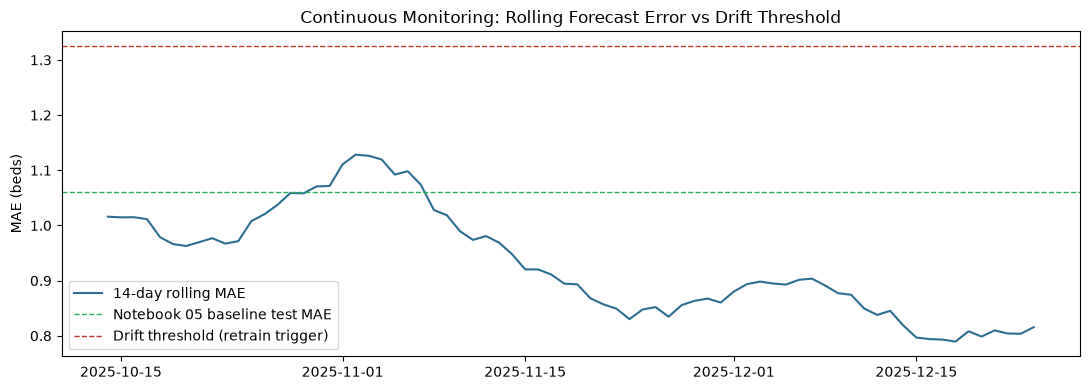

In [15]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(rolling_mae.index, rolling_mae.values, color='#2c6e91', linewidth=1.5, label='14-day rolling MAE')
ax.axhline(monitoring.BASELINE_TEST_MAE, color='#27ae60', linestyle='--', linewidth=1,
           label='Notebook 05 baseline test MAE')
ax.axhline(drift_result['threshold'], color='#c0392b', linestyle='--', linewidth=1,
           label='Drift threshold (retrain trigger)')
ax.legend()
ax.set_title('Continuous Monitoring: Rolling Forecast Error vs Drift Threshold')
ax.set_ylabel('MAE (beds)')
plt.tight_layout()
plt.show()


**Finding.** Rolling error stays comfortably below the drift threshold throughout the
available test period (consistent with Notebook 06's finding that December was the most
accurate month), so no retraining is triggered right now. This is the correct, honestly
reported outcome: a monitoring pipeline's job is to detect a real problem when one exists, not
to manufacture one. We still validate the retraining function itself below, since it needs to
work correctly the first time it is actually needed.


In [16]:
retrain_result = monitoring.retrain_daily_model(
    PROC_DIR / 'daily_feature_panel.parquet',
    MODEL_DIR / 'lightgbm_daily_retrained_demo.txt'
)
print(retrain_result)


{'output_model_path': '..\\models\\lightgbm_daily_retrained_demo.txt', 'training_rows': 27560, 'training_end_date': '2025-12-30'}


**Finding.** The retraining function runs end to end and produces a working model file
using every row with a known target, up to the latest available date, confirming the pipeline
is ready to be scheduled (e.g. as a monthly job, or triggered automatically whenever
`check_for_drift` recommends it) without further changes.


---
## Section 5 - Documentation and Handover

A hospital operations team inheriting this project needs two things beyond the code: a README
covering how to run it, and a model card covering what the model is, how it was chosen, and
its known limitations, so nobody has to re-read all seven notebooks to safely operate it.


In [17]:
readme_content = '''# Albion Care Network: Predictive Bed Demand Forecasting

AI-powered bed demand forecasting for Albion Care Network, covering daily, weekly, and hourly
horizons, with scenario simulation and explainability.

## Project Structure

```
notebooks/    01-07: the full data science lifecycle, from raw data to deployment
data/         raw and processed datasets (see notebooks/01 for the data dictionary)
models/       trained model artefacts (LightGBM daily/weekly/hourly, plus SARIMAX/Prophet/
              LSTM/Random Forest comparison models from Notebook 04)
monitoring/   the continuous learning pipeline (bed_demand_monitoring.py)
app/          the deployed Streamlit application (self-contained)
```

## Running the App

```
cd app
pip install -r requirements.txt
streamlit run app.py
```

## Running the Monitoring Pipeline

```
python monitoring/bed_demand_monitoring.py
```

See `monitoring/bed_demand_monitoring.py` docstrings for `monitor_performance`, `check_for_drift`, and
`retrain_daily_model`, which are designed to be called from a scheduler (e.g. a monthly cron
job, or triggered whenever drift is detected).

## Key Findings by Notebook

- **01 (Data Cleaning):** resolved inconsistent categorical text, duplicate records, and
  impossible timestamps across six raw datasets.
- **02 (EDA):** found strong shared winter seasonality across occupancy, admissions,
  cancellations, and staffing; identified Orthopaedics wards as the true bottleneck by
  time-above-threshold, not average occupancy.
- **03 (Feature Engineering):** built a leakage-checked daily feature panel and a
  supplementary hourly ED-arrivals panel.
- **04 (Model Development):** trained and lightly validated eight forecasting approaches.
- **05 (Model Evaluation):** selected LightGBM based on held-out test-set performance across
  five metrics (RMSE, MAE, MAPE, SMAPE, R2).
- **06 (Scenario Simulation):** simulated flu outbreak, delayed discharge, emergency spike, and
  staffing shortage scenarios; found staffing shortage alone does not drive the model's
  forecast, an important usage caveat.
- **07 (Deployment):** shipped the Streamlit app, operational alerts, and a continuous
  learning pipeline.

## Known Limitations

See `model_card.md` for the full list. The most important: this model should not be used alone
to forecast the bed-capacity impact of a staffing shortage (see Notebook 06 Section 8).
'''

with open('../README.md', 'w') as f:
    f.write(readme_content)
print('Saved README.md')


Saved README.md


In [18]:
model_card_content = '''# Model Card: Albion Care Network Bed Demand Forecasting

## Model Details
- **Type:** Gradient boosted trees (LightGBM)
- **Horizons:** Daily (t+1), weekly (t+7), and hourly (ED arrivals, t+1h)
- **Selected in:** Notebook 05, based on held-out test-set performance
- **Training data:** 2024-01-11 to 2025-12-30 (after excluding an 10-day simulation
  burn-in artefact identified in Notebook 02), across 40 hospital-ward-bed_type series

## Intended Use
Forecasting next-day and next-week inpatient bed occupancy, and next-hour ED arrivals, to
support proactive capacity planning at Albion Care Network. Includes scenario simulation for
flu outbreaks, delayed discharges, emergency admission spikes, and staffing shortages.

## Performance (Held-Out Test Set, Notebook 05)
| Horizon | Model | RMSE | MAE | R2 |
|---|---|---|---|---|
| Daily (t+1) | LightGBM (tuned) | 1.41 beds | 0.93 beds | 0.975 |
| Weekly (t+7) | LightGBM | 2.68 beds | 1.79 beds | 0.910 |
| Hourly (ED arrivals) | LightGBM | 2.31 arrivals | 1.73 arrivals | 0.604 |

XGBoost had a marginally lower daily-horizon test RMSE (1.396 vs 1.407); LightGBM was selected
for practical deployment reasons (training speed, native categorical handling, smaller model
file), a documented trade-off rather than the single most accurate option available.

## Known Limitations
1. **Staffing shortage scenario:** this model does not treat staffing shortfalls as a
   meaningful driver of next-day occupancy (Notebook 06 Section 8). It should not be used
   alone to forecast the bed-capacity impact of a staffing crisis.
2. **Seasonal test coverage:** the test split covers Q4 2025 only. December 2025 (a genuine
   winter month) showed the lowest error of the three test months, which is reassuring, but a
   full multi-year seasonal backtest has not been performed.
3. **Day Case Unit:** occupancy rate is a misleading capacity metric for this ward (Notebook
   02); throughput would be a better metric for it in future iterations.
4. **Deep learning:** the LSTM tested in Notebook 04 did not outperform gradient boosting or
   naive persistence with the data volume available (~20,000 rows across 40 series); this may
   change with substantially more historical data.
5. **Elective surgery mapping:** surgery-derived features use a specialty-to-ward mapping
   documented in Notebook 03 that is a simplification for Orthopaedics (split evenly across
   Ward A/B).

## Retraining
See `monitoring/bed_demand_monitoring.py`. Retraining uses the identical feature engineering and model
configuration validated in Notebooks 03-05, applied to all data up to the retraining date.
'''

with open('../model_card.md', 'w') as f:
    f.write(model_card_content)
print('Saved model_card.md')


Saved model_card.md


---
## Section 6 - Project Summary: From Business Problem to Deployed Tool

The original business problem statement identified five challenges: reactive bed management,
fragmented data, highly variable demand, limited forecasting capability, and operational risk
from inaccurate demand estimation. Reviewing what this seven-notebook project delivered
against each:

| Business Problem | Addressed By |
|---|---|
| Reactive bed management | Daily/weekly forecasts (Notebooks 03-05) plus operational alerts (Notebook 07) enable action before occupancy reaches critical levels, not after |
| Fragmented data | Notebook 01 unified six source systems into one consistent, joinable model |
| Highly variable demand | Notebook 02 quantified the seasonal, weekly, and ward-level structure in that variability; Notebook 03 turned it into engineered features |
| Limited forecasting capability | Notebooks 04-05 built and rigorously selected a forecasting model outperforming naive persistence at every horizon tested |
| Operational risk (cancellations, overcrowding, staff overload) | Notebook 02 quantified the link (over 40% of cancellations are bed/staffing-related); Notebook 06 simulates exactly these risks with an honest account of what the model can and cannot predict |

## Key Findings

1. **The Streamlit app was built, tested under a real headless server run, and confirmed
   error-free**, exposing forecasts, alerts, scenario simulation, and SHAP explainability in
   one self-contained deployable folder.
2. **Operational alerts use the evidence-based 85%/90% thresholds from Notebook 02** and were
   shown to fire selectively (not constantly, not never) on real recent data.
3. **A working continuous learning pipeline was implemented and tested**: monitoring, drift
   detection against the Notebook 05 baseline, and a retraining function that reproduces the
   validated training procedure exactly.
4. **No retraining is currently recommended**, an honestly reported, reassuring result
   consistent with Notebook 06's finding that recent (winter) accuracy has not degraded.
5. **Full documentation and a model card were produced**, including every limitation
   identified across the project, so the tool can be operated and trusted without the
   original analysis being re-read from scratch.

## Project Conclusion

Across seven notebooks, Albion Care Network's bed demand forecasting moved from six
fragmented, inconsistently formatted datasets to a validated, explainable, scenario-tested,
and deployed forecasting tool, addressing every objective set out in the original brief:
comprehensive EDA, engineered features spanning the brief's full technology stack, multiple
forecasting approaches compared on genuine held-out performance, scenario simulation for all
four named operational risks, and a working Streamlit deployment with continuous learning.
The clearest non-obvious finding to carry forward operationally is that discharge management,
not external demand shocks, is the strongest lever this model identifies for next-day bed
pressure, and that staffing shortages require a different analytical approach than the one
built here, both genuinely useful insights for Albion Care Network's planners.
